In [1]:
import pandas as pd
import sqlite3 

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Creating database connection
conn = sqlite3.connect('Healthcare_Db.db')

In [3]:
# Checking tables present in the database
tables = pd.read_sql_query("Select name from sqlite_master where type='table'",conn)
tables

,name
0,healthcare_data


### Extracting only the relevant data(table view) from database using SQL




In [4]:
pd.read_sql_query("Select * from healthcare_data limit 5",conn)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
df = pd.read_sql_query("Select * from healthcare_data",conn)
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [6]:
hos_bill = pd.read_sql_query("""select hospital, "room number", round(sum("billing amount"),2) as avg_bill
                                from healthcare_data
                                group by hospital, "room number"
                                order by avg_bill desc""",conn)
hos_bill

,Hospital,Room Number,avg_bill
0,Johnson Inc,274,138513.38
1,Inc Williams,379,107842.56
2,Hernandez-Morton,181,104746.06
3,Walker-Garcia,306,104340.07
4,"and Small Stephens Harrington,",364,103951.94
...,...,...,...
49916,Armstrong LLC,193,-1660.01
49917,"Fitzpatrick, Nielsen and Mcdonald",402,-1774.05
49918,Juarez-Clark,162,-2008.49
49919,Johnson Inc,257,-2620.55


In [7]:
### Room number doesn't have much impact or correlation with billing amount and no significant inference can be made out of it
### thus we can drop this column from the final table

In [8]:
pd.read_sql_query("Select count(distinct name) from healthcare_data",conn)

,count(distinct name)
0,49992


In [9]:
df = pd.read_sql_query("""select name, age, gender, "blood type", "medical condition", "date of admission", doctor,
                       hospital, "insurance provider", "billing amount", "admission type", "discharge date", medication,
                       "test results" from healthcare_data""",conn)
df

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,Elective,2019-05-31,Ibuprofen,Abnormal


### Data Cleaning and Transformation

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Admission Type      55500 non-null  object 
 11  Discharge Date      55500 non-null  object 
 12  Medication          55500 non-null  object 
 13  Test Results        55500 non-null  object 
dtypes: float64(1), int64(1), object(12)
memory usage: 5.9+ MB


In [11]:
df.shape

(55500, 14)

In [12]:
# Formatting patient names
df['Name'] = df['Name'].str.title()

In [13]:
pd.read_sql_query("Select distinct gender from healthcare_data",conn)

,Gender
0,Male
1,Female


In [14]:
pd.read_sql_query("""Select distinct "blood type" from healthcare_data""",conn)

,Blood Type
0,B-
1,A+
2,A-
3,O+
4,AB+
5,AB-
6,B+
7,O-


In [15]:
pd.read_sql_query("""Select distinct "medical condition" from healthcare_data""",conn)

,Medical Condition
0,Cancer
1,Obesity
2,Diabetes
3,Asthma
4,Hypertension
5,Arthritis


In [16]:
pd.read_sql_query("""Select distinct "insurance provider" from healthcare_data""",conn)

,Insurance Provider
0,Blue Cross
1,Medicare
2,Aetna
3,UnitedHealthcare
4,Cigna


In [17]:
pd.read_sql_query("""Select distinct "admission type" from healthcare_data""",conn)

,Admission Type
0,Urgent
1,Emergency
2,Elective


In [18]:
pd.read_sql_query("""Select distinct medication from healthcare_data""",conn)

,Medication
0,Paracetamol
1,Ibuprofen
2,Aspirin
3,Penicillin
4,Lipitor


In [19]:
pd.read_sql_query("""Select distinct "test results" from healthcare_data""",conn)

,Test Results
0,Normal
1,Inconclusive
2,Abnormal


In [20]:
pd.read_sql_query("""Select min("Date of Admission"), max("Date of Admission"), min("Discharge date"), max("Discharge date") from healthcare_data""",conn)

,"min(""Date of Admission"")","max(""Date of Admission"")","min(""Discharge date"")","max(""Discharge date"")"
0,2019-05-08,2024-05-07,2019-05-09,2024-06-06


In [21]:
pd.read_sql_query("""Select * from healthcare_data where "billing amount"<0""",conn)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,ashLEy ERIcKSoN,32,Female,AB-,Cancer,2019-11-05,Gerald Hooper,"and Johnson Moore, Branch",Aetna,-502.507813,376,Urgent,2019-11-23,Penicillin,Normal
1,CHRisTOPHer wEiss,49,Female,AB-,Asthma,2023-02-16,Kelly Thompson,Hunter-Hughes,Aetna,-1018.245371,204,Elective,2023-03-09,Penicillin,Inconclusive
2,AsHley WaRnER,60,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
3,JAY galloWaY,74,Female,O+,Asthma,2021-01-20,Debra Everett,Group Peters,Blue Cross,-109.097122,381,Emergency,2021-02-09,Ibuprofen,Abnormal
4,josHUa wilLIamSon,72,Female,B-,Diabetes,2021-03-21,Wendy Ramos,"and Huff Reeves, Dennis",Blue Cross,-576.727907,369,Urgent,2021-04-17,Aspirin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,JosEPh cOx,23,Male,AB-,Diabetes,2019-10-13,Peter Smith,Inc Ward,Blue Cross,-353.865186,271,Elective,2019-10-25,Lipitor,Inconclusive
104,AsHley WaRnER,55,Male,A+,Hypertension,2021-12-21,Andrea Bentley,"and Wagner, Lee Klein",Aetna,-306.364925,426,Elective,2022-01-11,Ibuprofen,Normal
105,dAnIel dRaKe,68,Female,B+,Hypertension,2020-04-24,Brett Ray,Carr Ltd,Aetna,-591.917419,426,Elective,2020-04-26,Lipitor,Abnormal
106,DR. micHaEl MckAy,64,Male,O+,Cancer,2019-05-31,Dawn Navarro,"Mcconnell and Rios, Clark",UnitedHealthcare,-199.663795,122,Urgent,2019-06-12,Ibuprofen,Abnormal


In [22]:
# There are 108 negative billing amount values which we will consider that insurance company denied a previously approved claim, and the amount was reversed.
# We can ignore these values in overall analysis as it seems to be very small part of data.

In [23]:
# # Convert to datetime type and change date format to 'DD-MM-YYYY'
df['Date of Admission'] = pd.to_datetime(df['Date of Admission']).dt.strftime('%d-%m-%Y')
df['Discharge Date'] = pd.to_datetime(df['Discharge Date']).dt.strftime('%d-%m-%Y')

In [24]:
df.nunique()

Name                  40235
Age                      77
Gender                    2
Blood Type                8
Medical Condition         6
Date of Admission      1827
Doctor                40341
Hospital              39876
Insurance Provider        5
Billing Amount        50000
Admission Type            3
Discharge Date         1856
Medication                5
Test Results              3
dtype: int64

In [25]:
### Creating some calculated columns

In [26]:
df['Length_of_stay'] = (pd.to_datetime(df['Discharge Date'], format='%d-%m-%Y') - pd.to_datetime(df['Date of Admission'], format='%d-%m-%Y')).dt.days

In [27]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 18, 35, 50, 65, 100], labels=['Child', 'Young Adult', 'Adult', 'Senior', 'Elderly'])

In [28]:
df['Billing_per_day'] = (df['Billing Amount'] / df['Length_of_stay']).round(2)

In [29]:
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Admission Type,Discharge Date,Medication,Test Results,Length_of_stay,Age_Group,Billing_per_day
0,Bobby Jackson,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,Urgent,02-02-2024,Paracetamol,Normal,2,Young Adult,9428.14
1,Leslie Terry,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.327287,Emergency,26-08-2019,Ibuprofen,Inconclusive,6,Senior,5607.22
2,Danny Smith,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,Emergency,07-10-2022,Aspirin,Normal,15,Elderly,1863.67
3,Andrew Watts,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,Elective,18-12-2020,Ibuprofen,Abnormal,30,Young Adult,1263.66
4,Adrienne Bell,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.317814,Urgent,09-10-2022,Penicillin,Abnormal,20,Adult,711.92


### Exploratory Data Analysis

In [30]:
df.describe()

,Age,Billing Amount,Length_of_stay,Billing_per_day
count,55500.000000,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,15.509009,3386.403045
std,19.602454,14211.454431,8.659600,5784.961572
min,13.000000,-2008.492140,1.000000,-443.510000
25%,35.000000,13241.224652,8.000000,854.807500
50%,52.000000,25538.069376,15.000000,1647.795000
75%,68.000000,37820.508436,23.000000,3200.585000
max,89.000000,52764.276736,30.000000,52211.850000


In [31]:
###  1. Cost Drivers Analysis
###   •	What are the main factors influencing high billing amounts? 
###   •	Are emergency admissions associated with higher billing than elective or urgent cases?

###  2. Insurance Impact
###   • Which insurance providers are linked to the highest and lowest average billing?
###   • Is there any correlation between insurance providers and the frequency of abnormal test results or longer hospital stays?

###  3. Claims Optimization
###   • Are there patterns of overbilling or outlier charges across hospitals or conditions?
###   • What is the average claim amount per insurance provider for specific conditions or treatments?
###   • How do test results and medication administered influence the final bill and insurance claims?


In [32]:
# formats nos. to 2 decimal places for better view
pd.set_option('display.float_format',lambda x: '%.2f' % x)

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

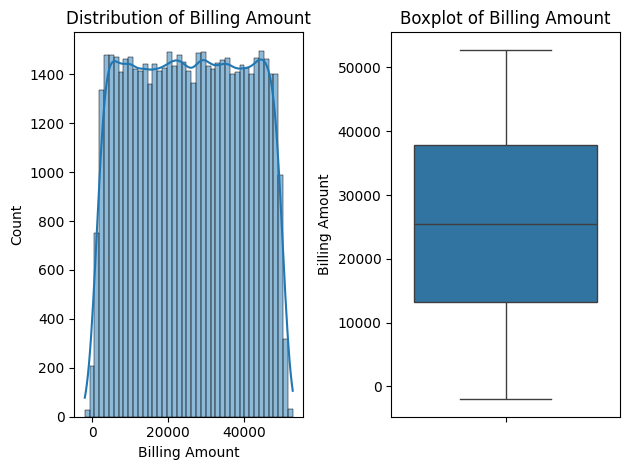

In [34]:
# Univariate Analysis of Billing Amount
plt.subplot(1,2,1)
sns.histplot(df['Billing Amount'], kde=True)
plt.title('Distribution of Billing Amount')

plt.subplot(1,2,2)
sns.boxplot(y=df['Billing Amount'])
plt.title('Boxplot of Billing Amount')

plt.tight_layout()
plt.show()

In [35]:
### There doesn't seems to be any significant outlier that may affect our analysis.

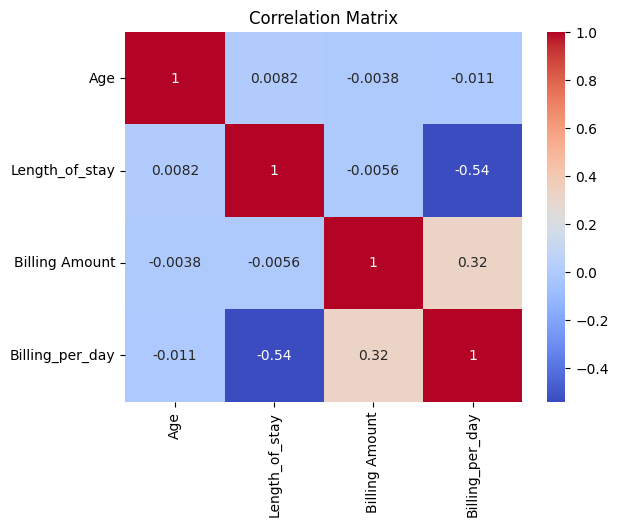

In [36]:
# Correlation with Numerical Variables

num_cols = ['Age', 'Length_of_stay', 'Billing Amount', 'Billing_per_day']
corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [37]:
# No significant correlation observed between numerical variables from heatmap.

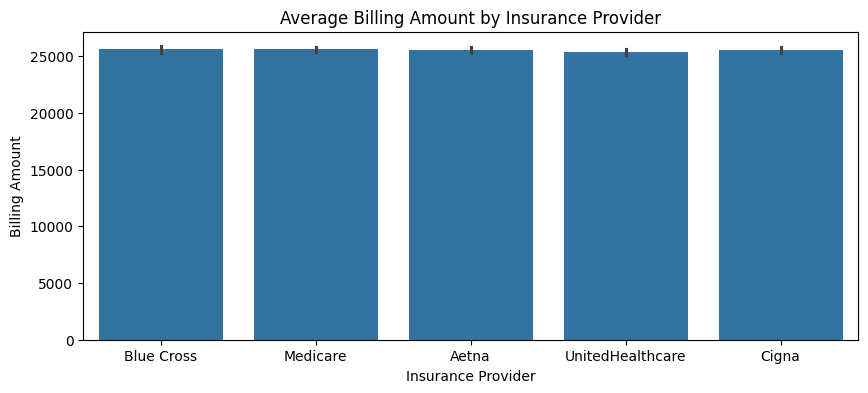

In [38]:
# Groupwise Analysis (Categorical Features vs Billing Amount)
cat_cols = ['Gender', 'Blood Type', 'Medical Condition', 'Doctor', 'Hospital',
            'Insurance Provider', 'Admission Type', 'Test Results', 'Age_Group']

fig = plt.figure(figsize=(10,4))
sns.barplot(x='Insurance Provider', y='Billing Amount', data=df)
plt.title('Average Billing Amount by Insurance Provider')
plt.show()

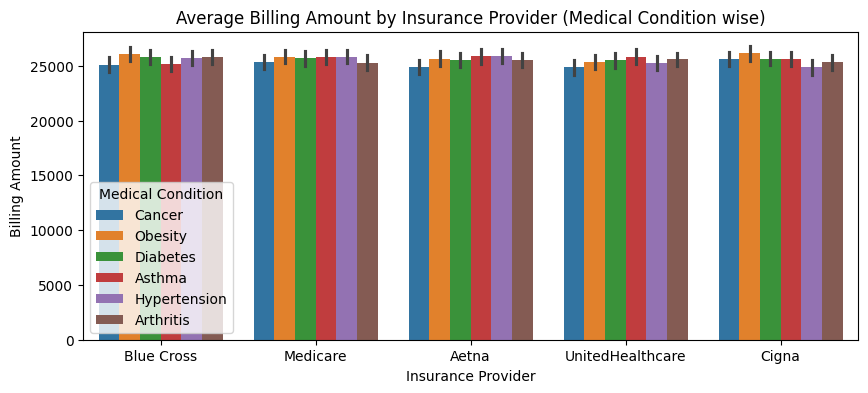

In [39]:
fig = plt.figure(figsize=(10,4))
sns.barplot(x='Insurance Provider', y='Billing Amount', data=df, hue='Medical Condition')
plt.title('Average Billing Amount by Insurance Provider (Medical Condition wise)')
plt.show()

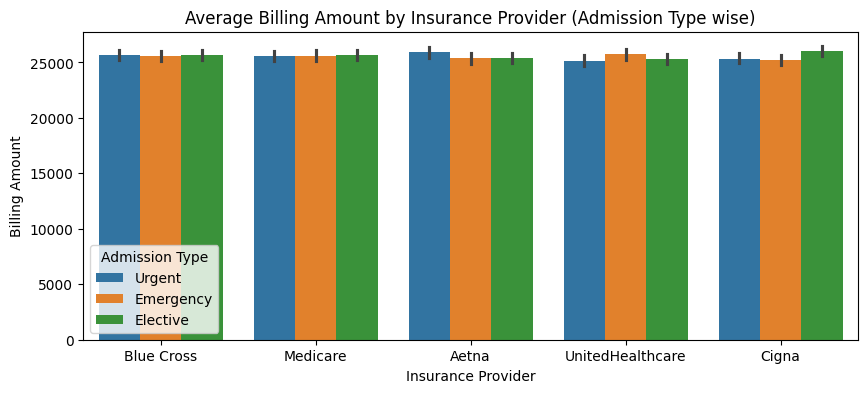

In [40]:
fig = plt.figure(figsize=(10,4))
sns.barplot(x='Insurance Provider', y='Billing Amount', data=df, hue='Admission Type')
plt.title('Average Billing Amount by Insurance Provider (Admission Type wise)')
plt.show()

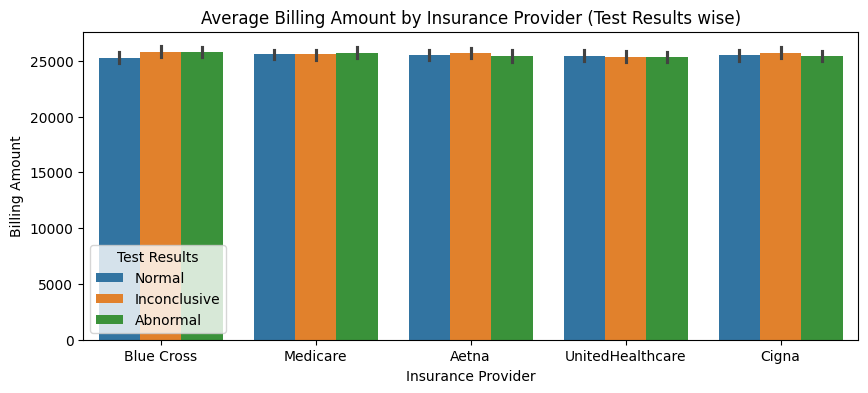

In [41]:
fig = plt.figure(figsize=(10,4))
sns.barplot(x='Insurance Provider', y='Billing Amount', data=df, hue='Test Results')
plt.title('Average Billing Amount by Insurance Provider (Test Results wise)')
plt.show()

In [42]:
### Having insured by any particular Insurance Provider doesn't seem to impact the medical bills.

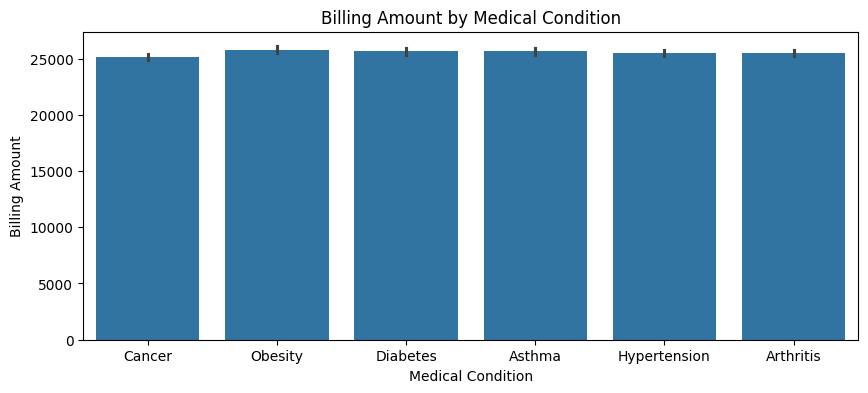

In [43]:
fig = plt.figure(figsize=(10,4))
sns.barplot(x='Medical Condition', y='Billing Amount', data=df)
plt.title('Billing Amount by Medical Condition')
plt.show()

In [44]:
# No impact of Medical Condition on Average Billing Amount.

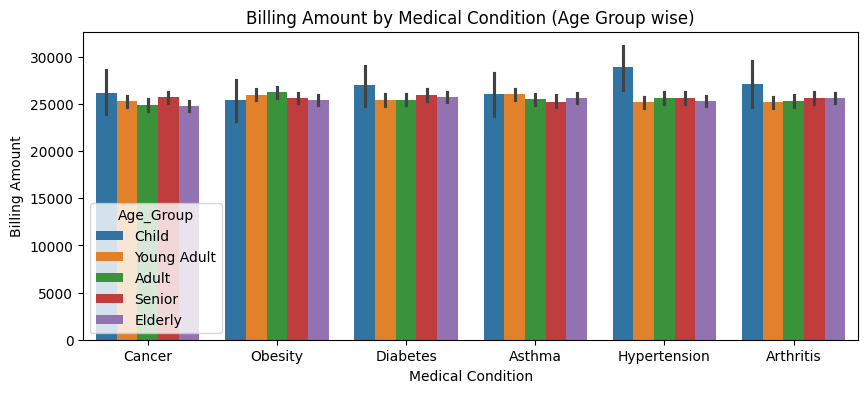

In [63]:
fig = plt.figure(figsize=(10,4))
sns.barplot(x='Medical Condition', y='Billing Amount', data=df, hue='Age_Group')
plt.title('Billing Amount by Medical Condition (Age Group wise)')
plt.savefig('Pics/bill_medicalcon_agewise.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
### Medical bills  of children are higher for most diseases compared to the other age groups for same medical condition.
### This phenomenon can be attributed to specialized treatment and care needed for children as these are generally life style diseases commonly occuring in senior and elderly age group. 

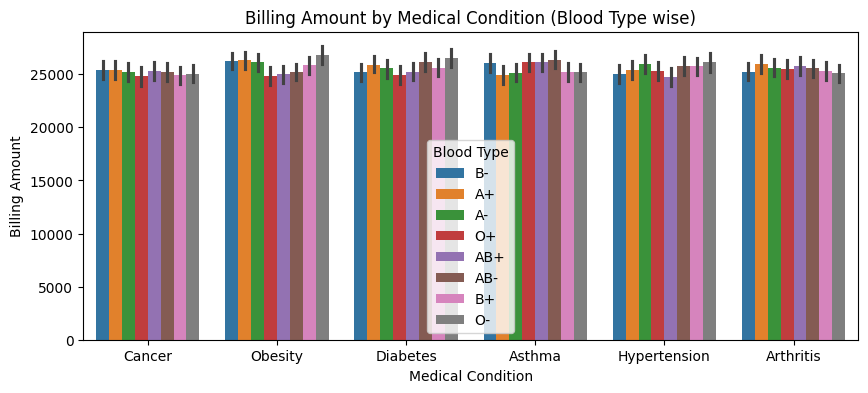

In [47]:
fig = plt.figure(figsize=(10,4))
sns.barplot(x='Medical Condition', y='Billing Amount', data=df, hue='Blood Type')
plt.title('Billing Amount by Medical Condition (Blood Type wise)')
plt.show()

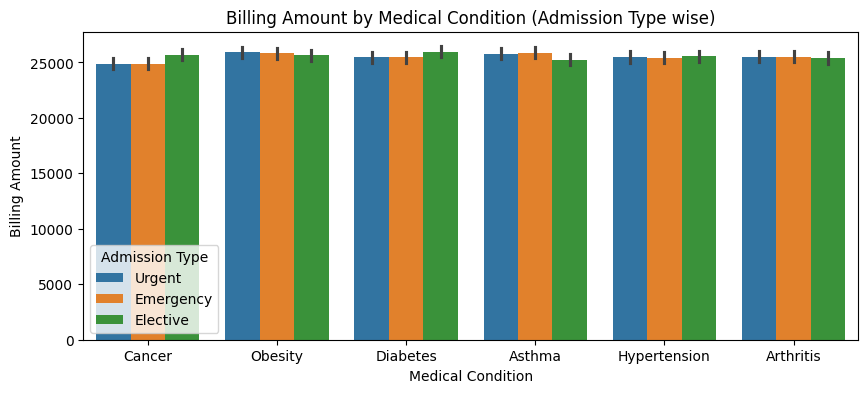

In [48]:
fig = plt.figure(figsize=(10,4))
sns.barplot(x='Medical Condition', y='Billing Amount', data=df, hue='Admission Type')
plt.title('Billing Amount by Medical Condition (Admission Type wise)')
plt.show()

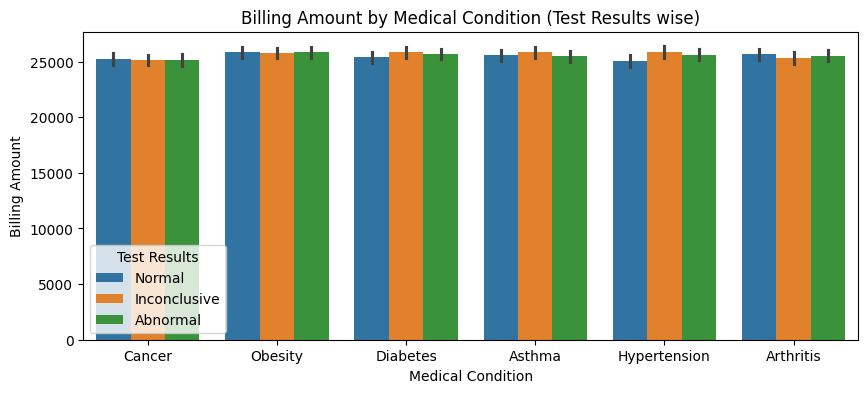

In [49]:
fig = plt.figure(figsize=(10,4))
sns.barplot(x='Medical Condition', y='Billing Amount', data=df, hue='Test Results')
plt.title('Billing Amount by Medical Condition (Test Results wise)')
plt.show()

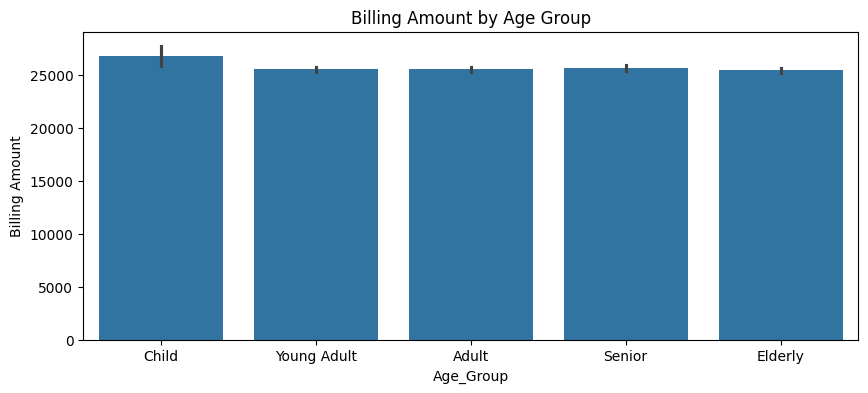

In [50]:
fig = plt.figure(figsize=(10,4))
sns.barplot(x='Age_Group', y='Billing Amount', data=df)
plt.title(f'Billing Amount by Age Group')
plt.show()

In [51]:
### The above plot confirms our previous observation of slightly higher Medical Charges associated with children as compared to other age groups.

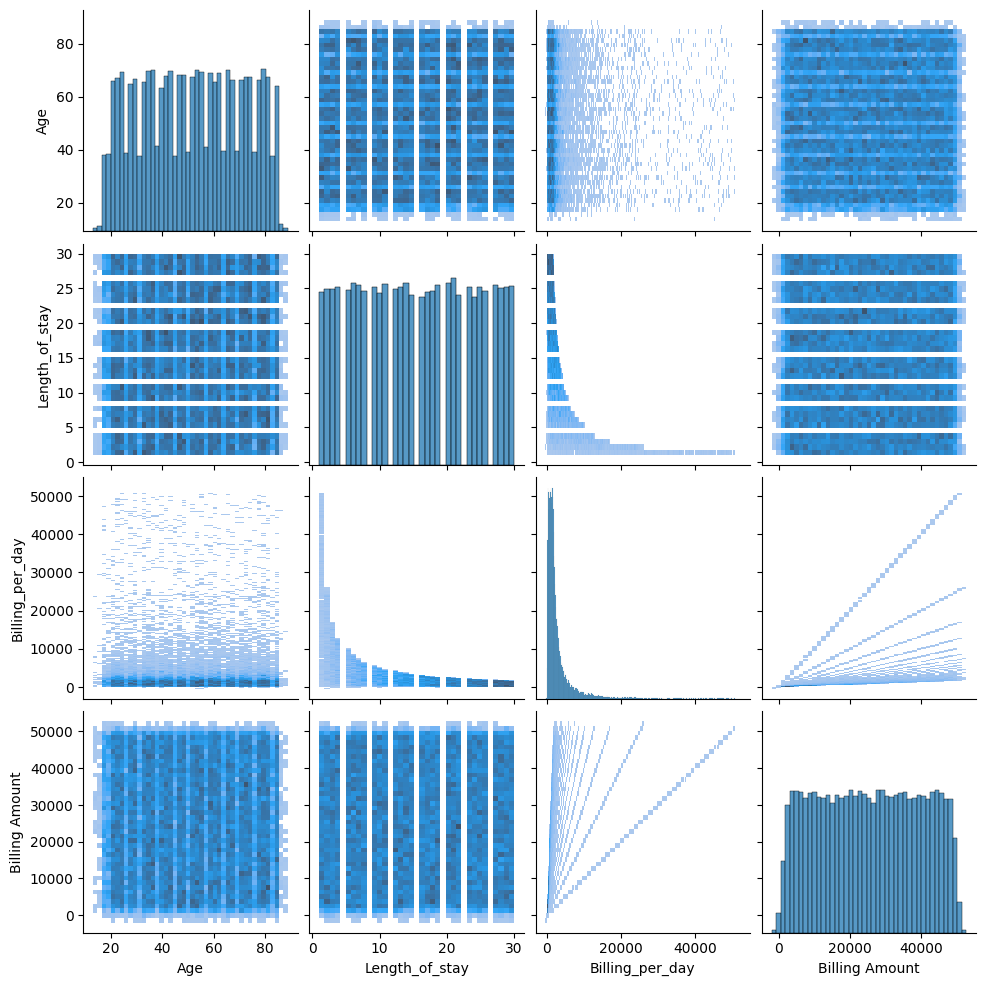

In [52]:
# Multivariate Analysis: Pairplot
sns.pairplot(df[['Age', 'Length_of_stay', 'Billing_per_day', 'Billing Amount']], kind='hist', palette='Blues')
plt.show()

In [53]:
### The Average Billing Amount reduces with increase in Length of Stay in hospital.

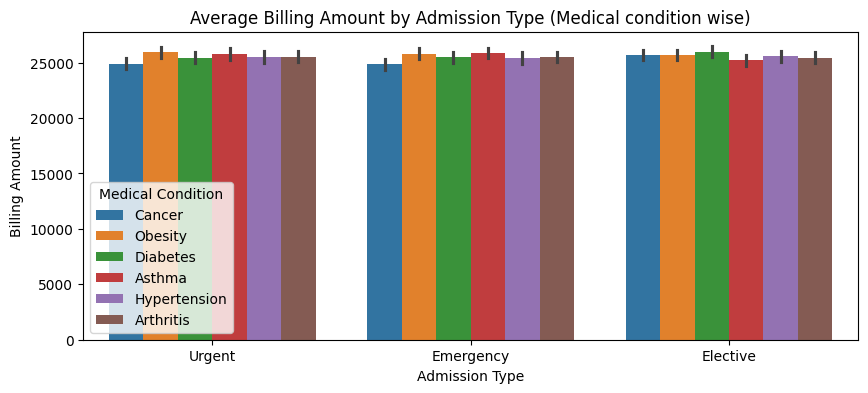

In [64]:
fig = plt.figure(figsize=(10,4))
sns.barplot(x='Admission Type', y='Billing Amount', data=df, hue='Medical Condition')
plt.title('Average Billing Amount by Admission Type (Medical condition wise)')
plt.savefig('Pics/bill_admissiontype_medconwise.png', dpi=300, bbox_inches='tight')
plt.show()

In [55]:
### No significant impact of Admission type on Average Billing Amount.

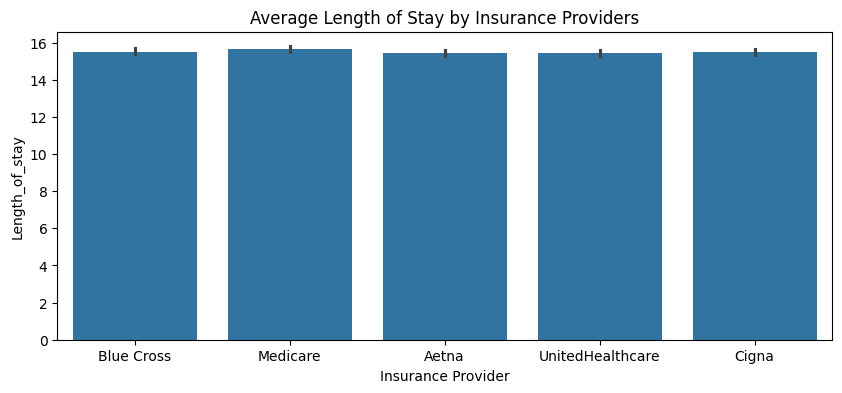

In [56]:
fig = plt.figure(figsize=(10,4))
sns.barplot(x='Insurance Provider', y='Length_of_stay', data=df)
plt.title(f'Average Length of Stay by Insurance Providers')
plt.show()

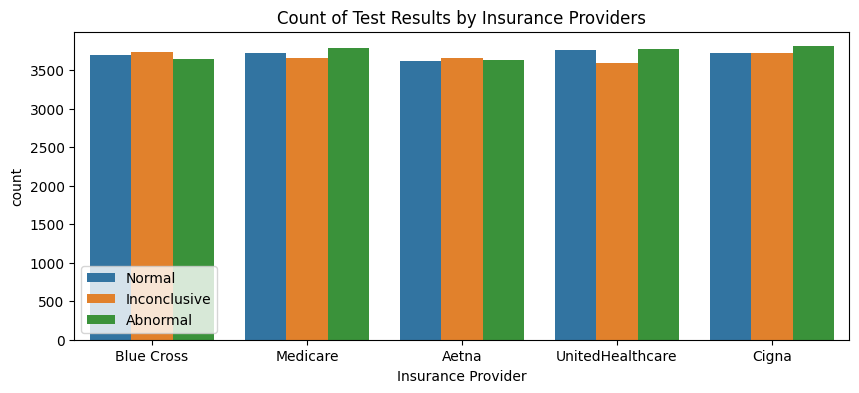

In [57]:
count = df['Test Results'].value_counts()

plt.figure(figsize=(10,4))
sns.countplot(x='Insurance Provider', data=df, hue='Test Results')
plt.title('Count of Test Results by Insurance Providers')
plt.legend(loc=3)
plt.show()

In [58]:
### There seems to be no significant correlation between Insurance Providers and the frequency of abnormal test results or longer hospital stays.

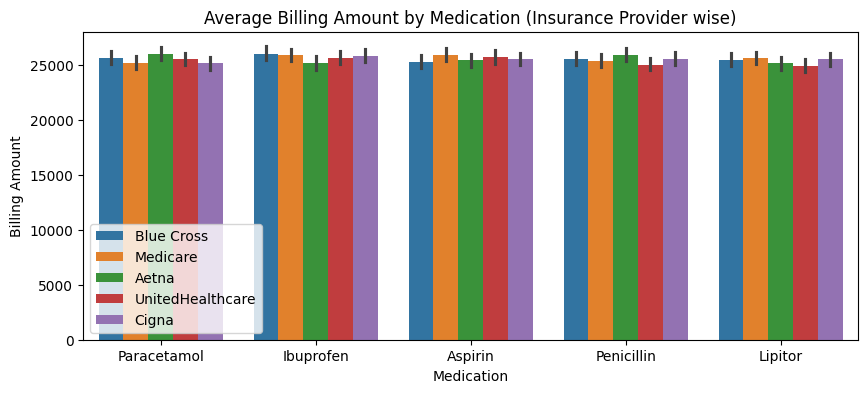

In [59]:
plt.figure(figsize=(10,4))
sns.barplot(x='Medication', y='Billing Amount', data=df, hue='Insurance Provider')
plt.title('Average Billing Amount by Medication (Insurance Provider wise)')
plt.legend(loc=3)
plt.show()

### Exporting Processed data to csv file

In [60]:
df.to_csv('Healthcare_data_processed.csv', index=False)

### Key Observations 

In [61]:
#  1. Medical bills  of children are higher for most diseases compared to the other age groups for same medical condition.
#     This phenomenon can be attributed to specialized treatment and care needed for children as these are generally life style diseases 
#     commonly occuring in senior and elderly age group. 

#  2. The Average Billing Amount reduces with increase in Length of Stay in hospital.

### Recommendations 

In [62]:
# 1. For Insurance Buyers :

#    - Buying insurance for children having chronic diseases can be beneficial in long term and help in managing medical expenses.
#    - Most of the patients belong to the Elderly Age Group as these chronic diseases are common in old age so having medical insurance would be helpful 
#      to reduce the burden of medical expenses for senior and elderly population.

# 2. For Insurance Companies :

#    - Can design custom Insurance plans specially for children covering long hospital stays, diagnostics and medical checkups.
#    - Adjust age stratified premium pricing models to increase coverage proportion for children.
#    - Provide preventive health programs and offer discounts and rewards for wellness program participation and regular health checkups.
#    - Partner with pedriatric hospitals and clinics and Negotiate pre-packaged pricing for frequent treatments.
#    - Having the Insurance buyer go through a basic medical checkup/diagnosis for common chronic diseases to screen out and propose premium plans accordingly.
#      This would create transparency and build trust.
